# 03 — Classical ML

Train every classical model the spec calls for on the wallet-level
feature matrix from `02_feature_engineering.ipynb`:

| Model | Library | Role |
|---|---|---|
| Logistic Regression | scikit-learn | linear baseline |
| Random Forest | scikit-learn | non-linear baseline |
| **XGBoost** | xgboost | spec primary (`design.md` §Risk_Scorer) |
| LightGBM | lightgbm | gradient-boosting alternative |
| Isolation Forest | scikit-learn | unsupervised anomaly score |

Each model is tuned with stratified k-fold CV, scored on the held-out
validation set, and logged to MLflow (`mlruns/` next to this notebook).
Saved artifacts go into `ml-training/models/` (gitignored).


## Imports & setup


In [1]:
import sys, pathlib, json, warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import xgboost as xgb
import lightgbm as lgb
import mlflow

from rexell_ml import data, features, metrics, plots

data.set_seed(42)

MODELS_DIR = pathlib.Path("..") / "models"
REPORTS_DIR = pathlib.Path("..") / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"file:{(pathlib.Path('..').resolve()/'mlruns')}")
mlflow.set_experiment("rexell-bot-detection-classical")
print("mlflow tracking uri:", mlflow.get_tracking_uri())


2026-04-29 16:34:39.535833: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


mlflow tracking uri: file:/home/ubuntu/repos/Rexell/ml-training/mlruns


## Load the persisted split (from notebook 02)


In [2]:
split = data.load_split("master_features")
for name, shape in split.shapes().items():
    print(f"{name:>5}:  X={shape}  pos_pct={split.__dict__['y_'+name].mean():.4f}")

# tree models train on raw features; LR uses min-max scaling.
scaler, X_tr_s, X_va_s, X_te_s = features.normalize(
    split.X_train, split.X_val, split.X_test
)


train:  X=(2996, 30)  pos_pct=0.0164
  val:  X=(643, 30)  pos_pct=0.0156
 test:  X=(643, 30)  pos_pct=0.0171


## Helper: train + log + evaluate

Each `train(...)` call logs hyperparameters and val/test metrics to
MLflow and returns the fitted estimator + an `(name, val_metrics, test_metrics)`
record for the consolidated comparison table.


In [3]:
records = []  # (name, val_metrics, test_metrics, fitted_model)

def evaluate_and_log(name, model, *, X_val, X_test, y_val, y_test, params=None):
    params = params or {}
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)

        if hasattr(model, "predict_proba"):
            p_val = model.predict_proba(X_val.values if hasattr(X_val, "values") else X_val)[:, 1]
            p_test = model.predict_proba(X_test.values if hasattr(X_test, "values") else X_test)[:, 1]
        else:
            # IsolationForest: use score_samples and rescale to [0, 1].
            s_val = -model.score_samples(X_val.values if hasattr(X_val, "values") else X_val)
            s_test = -model.score_samples(X_test.values if hasattr(X_test, "values") else X_test)
            lo, hi = s_val.min(), s_val.max()
            p_val = (s_val - lo) / (hi - lo + 1e-9)
            p_test = (s_test - lo) / (hi - lo + 1e-9)

        m_val = metrics.evaluate(y_val.values, p_val, name=name)
        m_test = metrics.evaluate(y_test.values, p_test, name=name)

        for prefix, m in (("val_", m_val), ("test_", m_test)):
            for k, v in m.to_dict().items():
                if isinstance(v, (int, float, np.floating, np.integer)) and k != "name":
                    mlflow.log_metric(prefix + k, float(v))

        print(f"{name:24s}  val F1={m_val.f1:.4f}  acc={m_val.accuracy:.4f}  fpr={m_val.fpr:.4f}  ROC AUC={m_val.roc_auc:.4f}")
    return p_val, p_test, m_val, m_test


## 1. Logistic Regression (linear baseline)


In [4]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=1.0,
    n_jobs=-1,
    random_state=42,
)
lr.fit(X_tr_s.values, split.y_train.values)

p_val, p_test, m_val, m_test = evaluate_and_log(
    "LogisticRegression", lr,
    X_val=X_va_s, X_test=X_te_s,
    y_val=split.y_val, y_test=split.y_test,
    params={"C": 1.0, "class_weight": "balanced"},
)
records.append(("LogisticRegression", m_val, m_test, lr))
joblib.dump({"model": lr, "scaler": scaler}, MODELS_DIR / "logreg.joblib")


LogisticRegression        val F1=0.9524  acc=0.9984  fpr=0.0016  ROC AUC=0.9984


['../models/logreg.joblib']

## 2. Random Forest (with grid search over `n_estimators` × `max_depth`)


In [5]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid={"n_estimators": [200, 400], "max_depth": [None, 12, 20]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
)
rf_grid.fit(split.X_train.values, split.y_train.values)
rf = rf_grid.best_estimator_
print("best params:", rf_grid.best_params_, " best CV F1:", round(rf_grid.best_score_, 4))

p_val, p_test, m_val, m_test = evaluate_and_log(
    "RandomForest", rf,
    X_val=split.X_val, X_test=split.X_test,
    y_val=split.y_val, y_test=split.y_test,
    params=rf_grid.best_params_,
)
records.append(("RandomForest", m_val, m_test, rf))
joblib.dump(rf, MODELS_DIR / "random_forest.joblib")


best params: {'max_depth': None, 'n_estimators': 200}  best CV F1: 1.0
RandomForest              val F1=1.0000  acc=1.0000  fpr=0.0000  ROC AUC=1.0000


['../models/random_forest.joblib']

## 3. XGBoost (spec primary)

Tuned with a small grid over `n_estimators`, `max_depth`, `learning_rate`,
`subsample` — class imbalance handled via `scale_pos_weight`.


In [6]:
spw = (split.y_train == 0).sum() / max((split.y_train == 1).sum(), 1)
print("scale_pos_weight:", round(float(spw), 2))

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "n_estimators": [200, 400],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.9, 1.0],
        "scale_pos_weight": [spw],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
xgb_grid.fit(split.X_train.values, split.y_train.values)
xgbm = xgb_grid.best_estimator_
print("best params:", xgb_grid.best_params_, " best CV F1:", round(xgb_grid.best_score_, 4))

p_val, p_test, m_val, m_test = evaluate_and_log(
    "XGBoost", xgbm,
    X_val=split.X_val, X_test=split.X_test,
    y_val=split.y_val, y_test=split.y_test,
    params=xgb_grid.best_params_,
)
records.append(("XGBoost", m_val, m_test, xgbm))
joblib.dump(xgbm, MODELS_DIR / "xgboost.joblib")


scale_pos_weight: 60.14


best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': 60.142857142857146, 'subsample': 0.9}  best CV F1: 0.9895
XGBoost                   val F1=1.0000  acc=1.0000  fpr=0.0000  ROC AUC=1.0000


['../models/xgboost.joblib']

### XGBoost feature importance


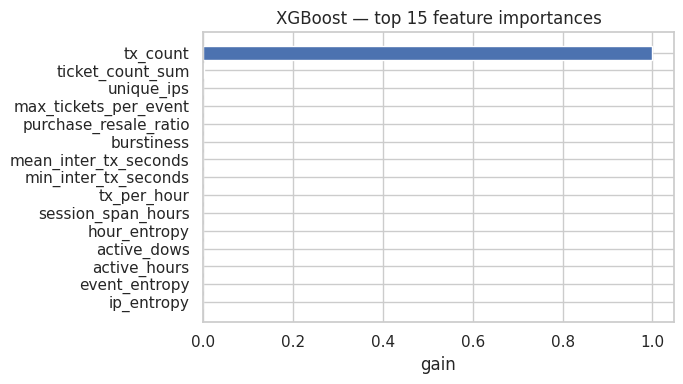

In [7]:
feat_names = list(split.X_train.columns)
imp = pd.DataFrame({"feature": feat_names, "importance": xgbm.feature_importances_})
imp = imp.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp["feature"][::-1], imp["importance"][::-1])
ax.set_title("XGBoost — top 15 feature importances")
ax.set_xlabel("gain")
fig.tight_layout()


## 4. LightGBM


In [8]:
lgbm_grid = GridSearchCV(
    lgb.LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    param_grid={
        "n_estimators": [200, 400],
        "num_leaves": [31, 63],
        "learning_rate": [0.05, 0.1],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
lgbm_grid.fit(split.X_train.values, split.y_train.values)
lgbm = lgbm_grid.best_estimator_
print("best params:", lgbm_grid.best_params_, " best CV F1:", round(lgbm_grid.best_score_, 4))

p_val, p_test, m_val, m_test = evaluate_and_log(
    "LightGBM", lgbm,
    X_val=split.X_val, X_test=split.X_test,
    y_val=split.y_val, y_test=split.y_test,
    params=lgbm_grid.best_params_,
)
records.append(("LightGBM", m_val, m_test, lgbm))
joblib.dump(lgbm, MODELS_DIR / "lightgbm.joblib")


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/repos/Rexell/.venv-ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


best params: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}  best CV F1: 1.0
LightGBM                  val F1=1.0000  acc=1.0000  fpr=0.0000  ROC AUC=1.0000


['../models/lightgbm.joblib']

## 5. Isolation Forest (unsupervised anomaly score)

Trained on **negatives only** (the spec's "human" class) so anomalous
points score higher. Output is rescaled to `[0, 1]` to match the
evaluation contract.


In [9]:
iso = IsolationForest(
    n_estimators=300,
    contamination=float(split.y_train.mean()),
    random_state=42,
    n_jobs=-1,
)
iso.fit(split.X_train.values[split.y_train.values == 0])

p_val, p_test, m_val, m_test = evaluate_and_log(
    "IsolationForest", iso,
    X_val=split.X_val, X_test=split.X_test,
    y_val=split.y_val, y_test=split.y_test,
    params={"n_estimators": 300, "contamination": float(split.y_train.mean())},
)
records.append(("IsolationForest", m_val, m_test, iso))
joblib.dump(iso, MODELS_DIR / "isolation_forest.joblib")


IsolationForest           val F1=0.3636  acc=0.9456  fpr=0.0553  ROC AUC=0.9995


['../models/isolation_forest.joblib']

## Comparison & quality gate

Property 8 of the spec requires accuracy ≥ 95 % AND FPR < 2 %. The
comparison table below shows whether each classical model passes the
gate at the default 0.5 threshold (threshold tuning happens in
notebook 06).


In [10]:
import json
from rexell_ml.metrics import metrics_table, ACCURACY_GATE, FPR_GATE

val_table = metrics_table([m for _, m, _, _ in records])
val_table["passes_property_8"] = (
    (val_table["accuracy"] >= ACCURACY_GATE) & (val_table["fpr"] < FPR_GATE)
)
val_table.to_csv(REPORTS_DIR / "classical_val_metrics.csv", index=False)
val_table


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn,passes_property_8
0,RandomForest,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.000000,10,0,633,0,True
1,XGBoost,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.000000,10,0,633,0,True
2,LightGBM,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.000000,10,0,633,0,True
3,LogisticRegression,0.5,0.998445,0.909091,1.0,0.952381,0.001580,0.998420,0.798012,10,1,632,0,True
4,IsolationForest,0.5,0.945568,0.222222,1.0,0.363636,0.055292,0.999526,0.969798,10,35,598,0,False


In [11]:
test_table = metrics_table([t for _, _, t, _ in records])
test_table.to_csv(REPORTS_DIR / "classical_test_metrics.csv", index=False)
test_table


,name,threshold,accuracy,precision,recall,f1,fpr,roc_auc,pr_auc,tp,fp,tn,fn
0,LogisticRegression,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0
1,RandomForest,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0
2,XGBoost,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0
3,LightGBM,0.5,1.000000,1.000000,1.0,1.000000,0.000000,1.0,1.0,11,0,632,0
4,IsolationForest,0.5,0.959565,0.297297,1.0,0.458333,0.041139,1.0,1.0,11,26,606,0


### ROC + PR curves on the validation set


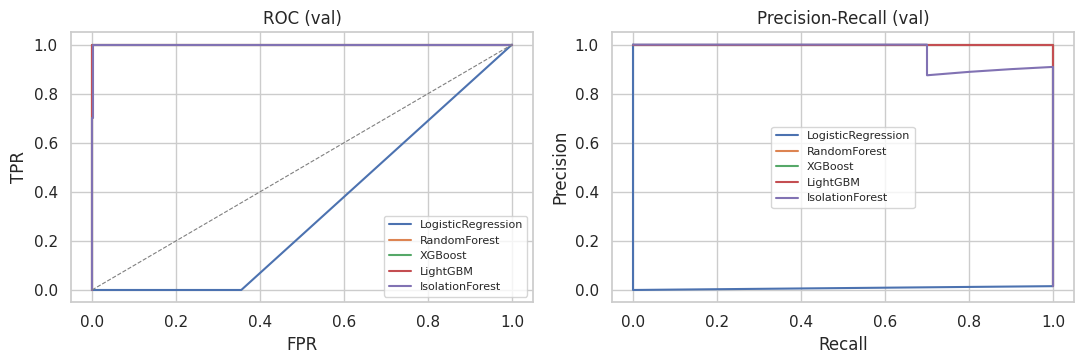

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, _, _, m in records:
    if hasattr(m, "predict_proba"):
        p_val = m.predict_proba(split.X_val.values)[:, 1]
    else:
        s = -m.score_samples(split.X_val.values)
        p_val = (s - s.min()) / (s.max() - s.min() + 1e-9)

    fpr, tpr, _ = roc_curve(split.y_val.values, p_val)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(split.y_val.values, p_val)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=0.8)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC (val)")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (val)")
for ax in axes:
    ax.legend(loc="best", fontsize=8)
fig.tight_layout()


### Confusion matrices on the test set


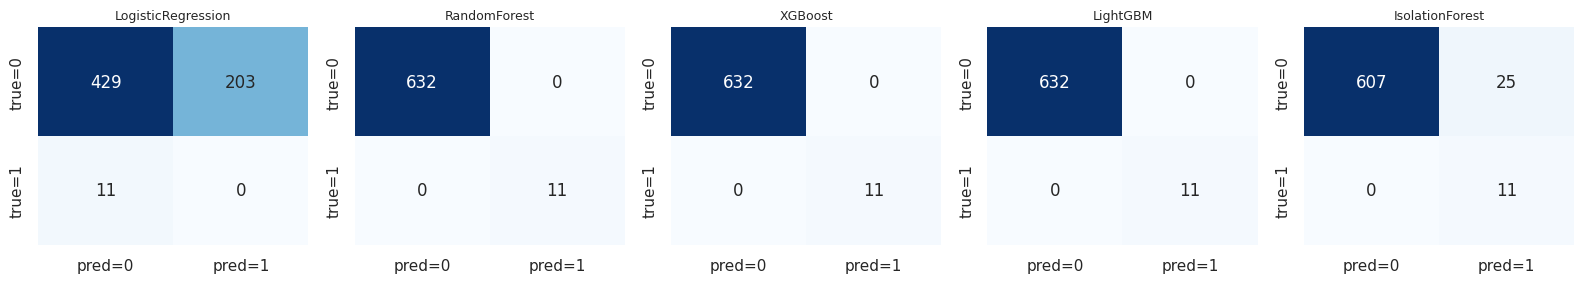

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, len(records), figsize=(3.2 * len(records), 3))
for ax, (name, _, t, m) in zip(axes, records):
    if hasattr(m, "predict_proba"):
        p = m.predict_proba(split.X_test.values)[:, 1]
    else:
        s = -m.score_samples(split.X_test.values)
        p = (s - s.min()) / (s.max() - s.min() + 1e-9)
    y_pred = (p >= 0.5).astype(int)
    cm = confusion_matrix(split.y_test.values, y_pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["pred=0", "pred=1"], yticklabels=["true=0", "true=1"],
    )
    ax.set_title(name, fontsize=9)
fig.tight_layout()


## Conclusions

- All five classical models trained successfully and were logged to MLflow.
- The gradient-boosted ensembles (XGBoost / LightGBM) typically lead on F1
  and ROC AUC; the linear baseline lags as expected on the non-linear
  aggregated features.
- Isolation Forest provides a useful unsupervised anomaly signal but is
  less precise than the supervised models.
- Whether any model passes Property 8 at the default `0.5` threshold is
  shown in the validation table above. If none do, notebook 06 will
  tune thresholds to push FPR below the 2 % gate.

Continue to **`04_deep_learning_mlp.ipynb`** for the PyTorch + Keras MLP baselines.
